In [1]:
!pip install --upgrade pip setuptools wheel -q
!pip install --upgrade cmake -q
!pip install scs --prefer-binary -q
!pip install cvxpy --prefer-binary -q
!pip install awswrangler -q
!pip install optbinning -q
!pip install lightgbm
!pip install xgboost
!pip install xgboost --prefer-binary
!pip install catboost


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Program Files\Python314\python.exe -m pip install --upgrade pip setuptools wheel -q

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program F

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [2]:
import awswrangler as wr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from optbinning import BinningProcess
import shutil
from warnings import simplefilter
simplefilter(action = "ignore") #, category = FutureWarning

pd.set_option('display.max_rows', 500)
from sklearn.preprocessing import LabelEncoder

(CVXPY) Aug 28 09:14:17 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Aug 28 09:14:17 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.15.6755). Expected < 9.15.0. Please open a feature request on cvxpy to enable support for this version.')


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple
#import plotly.graph_objects as go
#from plotly.subplots import make_subplots
import os
#import plotly.express as px

pd.set_option('display.float_format', '{:.2f}'.format)

In [4]:
# === Conexion Athena estilo Cruce + fallback awswrangler ===
import os
import re
import sys
from pathlib import Path

import boto3
import awswrangler as wr
import pandas as pd

EXPLICIT_CREDENTIALS_SH = Path(r"c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test/credentials.sh")


def _find_dir_with_athena_client(preferred_dir: Path | None = None) -> Path | None:
    cwd = Path.cwd().resolve()
    search_roots = []

    if preferred_dir is not None:
        search_roots.append(preferred_dir)

    search_roots.extend([cwd, *cwd.parents])

    home = Path.home()
    search_roots.extend([
        home / "OneDrive - Interbank" / "conexion_aws" / "athena_conection_test",
        Path("c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test"),
    ])

    visited = set()
    for root in search_roots:
        if root in visited:
            continue
        visited.add(root)

        if not root.exists():
            continue
        if (root / "athena_client.py").exists() and (root / "athena_config.json").exists():
            return root
    return None


def _load_credentials_from_sh(sh_path: Path) -> list[str]:
    if not sh_path.exists():
        return []

    loaded_keys: list[str] = []
    pattern = re.compile(r'^\s*export\s+([A-Za-z_][A-Za-z0-9_]*)=(.*)$')

    for line in sh_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        match = pattern.match(line)
        if not match:
            continue

        key, raw_val = match.groups()
        value = raw_val.strip().strip('"').strip("'")
        if key and value:
            os.environ[key] = value
            loaded_keys.append(key)

    return loaded_keys


def _build_session(aws_region: str) -> boto3.Session:
    aws_profile = os.getenv("AWS_PROFILE")
    if aws_profile:
        return boto3.Session(profile_name=aws_profile, region_name=aws_region)
    return boto3.Session(region_name=aws_region)


def _session_is_valid(sess: boto3.Session) -> tuple[bool, str | None]:
    try:
        sts = sess.client("sts")
        _ = sts.get_caller_identity()
        return True, None
    except Exception as exc:
        return False, str(exc)


ATHENA_MODE = "wrangler"
ATHENA_DATABASE = os.getenv("ATHENA_DATABASE", "disc_comercial")
ATHENA_WORKGROUP = os.getenv("ATHENA_WORKGROUP", "primary")
ATHENA_OUTPUT = os.getenv(
    "ATHENA_OUTPUT",
    "s3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/athena_results/"
 )
AWS_REGION = os.getenv("AWS_REGION", "us-east-1")

client = None

credentials_file = EXPLICIT_CREDENTIALS_SH if EXPLICIT_CREDENTIALS_SH.exists() else None
if credentials_file is None:
    print(f"⚠ No se encontró credentials.sh en ruta fija: {EXPLICIT_CREDENTIALS_SH}")

preferred_dir = credentials_file.parent if credentials_file is not None else None
athena_dir = _find_dir_with_athena_client(preferred_dir=preferred_dir)
loaded_cred_keys: list[str] = []

if credentials_file is not None:
    loaded_cred_keys = _load_credentials_from_sh(credentials_file)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {credentials_file}")
elif athena_dir is not None:
    fallback_sh = athena_dir / "credentials.sh"
    loaded_cred_keys = _load_credentials_from_sh(fallback_sh)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {fallback_sh}")

try:
    session = _build_session(AWS_REGION)
except Exception:
    session = boto3.Session(region_name=AWS_REGION)

ok_session, session_error = _session_is_valid(session)
if not ok_session and session_error and "ExpiredToken" in session_error and loaded_cred_keys:
    print("⚠ Se detectó token expirado en credentials.sh. Reintentando con credenciales locales (perfil/default)...")
    for key in ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_SESSION_TOKEN"]:
        os.environ.pop(key, None)
    session = _build_session(AWS_REGION)

if athena_dir is not None:
    if str(athena_dir) not in sys.path:
        sys.path.append(str(athena_dir))
    try:
        from athena_client import AthenaClient

        if credentials_file is None:
            credentials_file = athena_dir / "credentials.sh"

        client = AthenaClient(
            credentials_file=str(credentials_file),
            config_file=str(athena_dir / "athena_config.json"),
        )
        ATHENA_MODE = "athena_client"
        print(f"✓ AthenaClient cargado desde: {athena_dir}")
    except Exception as exc:
        print(f"⚠ No se pudo inicializar AthenaClient ({exc}). Se usará awswrangler.")
else:
    print("⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.")


def athena_query(query: str, database: str = ATHENA_DATABASE) -> pd.DataFrame:
    if ATHENA_MODE == "athena_client" and client is not None:
        return client.query(query)
    return wr.athena.read_sql_query(
        sql=query,
        database=database,
        ctas_approach=False,
        boto3_session=session,
        workgroup=ATHENA_WORKGROUP,
        s3_output=ATHENA_OUTPUT,
    )


def s3_read_csv(path: str, sep: str = "|", **kwargs) -> pd.DataFrame:
    return wr.s3.read_csv(path=path, sep=sep, boto3_session=session, **kwargs)


def test_aws_connection(sample_s3_path: str | None = None) -> None:
    sts = session.client("sts")
    ident = sts.get_caller_identity()
    print(f"✓ AWS Account: {ident.get('Account')} | ARN: {ident.get('Arn')}")

    if sample_s3_path:
        _ = wr.s3.read_csv(path=sample_s3_path, sep='|', boto3_session=session, nrows=1)
        print(f"✓ Lectura S3 OK: {sample_s3_path}")


print(f"Modo Athena activo: {ATHENA_MODE}")
print(f"DB: {ATHENA_DATABASE} | WG: {ATHENA_WORKGROUP}")
print(f"credentials.sh en uso: {credentials_file}")
print("Helper Athena: athena_query(query)")
print("Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')")
print("Diagnóstico opcional: test_aws_connection()")

✓ Credenciales cargadas desde: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.
Modo Athena activo: wrangler
DB: disc_comercial | WG: primary
credentials.sh en uso: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
Helper Athena: athena_query(query)
Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')
Diagnóstico opcional: test_aws_connection()


In [5]:
%%time
query = """
WITH mst_plaft_trx_operaciones AS (

    SELECT
        cod_argcatalogo AS cod_trx,
        desc_argcatalogo AS des_trx,
        desc_valor02 AS tipo_transaccion,
        desc_valor03 AS actor

    FROM e_perm_aws.t_mst_parametros_plaft
    WHERE desc_catalogo = 'TIPO OPERACION'

),

base_operaciones AS (

    SELECT

        SUBSTR(o.fec_inicio_trx,1,4) ||
        SUBSTR(o.fec_inicio_trx,6,2) AS periodo,

        CASE
            WHEN p.actor = 'ORD'
                THEN o.codunico_ord
            ELSE o.codunico_ben
        END AS id_origen,

        CASE
            WHEN p.actor = 'ORD'
                THEN o.codunico_ben
            ELSE o.codunico_ord
        END AS id_destino,

        o.cod_trx_orig,
        p.des_trx,
        p.tipo_transaccion,

        o.mto_operacion,
        o.fec_inicio_trx

    FROM e_perm_aws.t_aml_operaciones o

    INNER JOIN mst_plaft_trx_operaciones p
        ON o.cod_trx_orig = p.cod_trx

    WHERE o.codunico_ord <> o.codunico_ben

)

SELECT

    periodo,

    id_origen,
    id_destino,

    cod_trx_orig,
    des_trx,
    tipo_transaccion,

    COUNT(*) AS cantidad_operaciones,

    SUM(mto_operacion) AS monto_total,

    AVG(mto_operacion) AS monto_promedio,

    MAX(mto_operacion) AS monto_maximo,

    MIN(fec_inicio_trx) AS fecha_primera_operacion,

    MAX(fec_inicio_trx) AS fecha_ultima_operacion

FROM base_operaciones

WHERE periodo =  '202604'

GROUP BY
    periodo,
    id_origen,
    id_destino,
    cod_trx_orig,
    des_trx,
    tipo_transaccion
;"""
df = athena_query(query, database='disc_comercial')
df.head()

CPU times: total: 1min 55s
Wall time: 14min 43s


,periodo,id_origen,id_destino,cod_trx_orig,des_trx,tipo_transaccion,cantidad_operaciones,monto_total,monto_promedio,monto_maximo,fecha_primera_operacion,fecha_ultima_operacion
0,202604,0009153758,0011356370,530,RETIRO TARJ.CONVENIO,<NA>,9,3330.00,370.00,370.00,2026/04/10,2026/04/10
1,202604,0013464776,0004148441,530,RETIRO TARJ.CONVENIO,<NA>,9,11430.00,1270.00,1270.00,2026/04/05,2026/04/05
2,202604,0012789815,0009220004,530,RETIRO TARJ.CONVENIO,<NA>,9,10980.00,1220.00,1220.00,2026/04/20,2026/04/20
3,202604,0010410327,0000000000,9640,OUTGOING-TRANSACTOR,EGRESO,45,20024073.63,444979.41,2080859.00,2026/04/08,2026/04/20
4,202604,0000000000,0003956711,9640,OUTGOING-TRANSACTOR,EGRESO,9,37375300.80,4152811.20,4152811.20,2026/04/24,2026/04/24


In [6]:

df.head()

,periodo,id_origen,id_destino,cod_trx_orig,des_trx,tipo_transaccion,cantidad_operaciones,monto_total,monto_promedio,monto_maximo,fecha_primera_operacion,fecha_ultima_operacion
0,202604,0009153758,0011356370,530,RETIRO TARJ.CONVENIO,<NA>,9,3330.00,370.00,370.00,2026/04/10,2026/04/10
1,202604,0013464776,0004148441,530,RETIRO TARJ.CONVENIO,<NA>,9,11430.00,1270.00,1270.00,2026/04/05,2026/04/05
2,202604,0012789815,0009220004,530,RETIRO TARJ.CONVENIO,<NA>,9,10980.00,1220.00,1220.00,2026/04/20,2026/04/20
3,202604,0010410327,0000000000,9640,OUTGOING-TRANSACTOR,EGRESO,45,20024073.63,444979.41,2080859.00,2026/04/08,2026/04/20
4,202604,0000000000,0003956711,9640,OUTGOING-TRANSACTOR,EGRESO,9,37375300.80,4152811.20,4152811.20,2026/04/24,2026/04/24


In [7]:
%%time
query = """
WITH base_cucibk AS (

    SELECT
        cod_cuc,
        key_value
    FROM (

        SELECT
            cod_cuc,
            key_value,
            ROW_NUMBER() OVER(
                PARTITION BY cod_cuc
                ORDER BY fch_priprd DESC
            ) rn

        FROM e_perm_aws.t_mst_ctaibk_rsk

    )
    WHERE rn = 1

),

cliente_pep AS (

    SELECT
        b.cod_cuc AS codunico,
        1 AS flag_pep,
        MAX(r3.cargo) AS cargo_pep,
        MAX(r3.sbs_fecha_inicio) AS fecha_inicio_pep,
        MAX(r3.sbs_fecha_cese) AS fecha_fin_pep

    FROM base_cucibk b

    INNER JOIN e_perm_aws.t_listas_nivel_de_riesgos_motivo_r3 r3
        ON b.key_value = r3.key_value

    GROUP BY 1

),

alertas AS (

    SELECT

        codunico,

        MAX(
            CASE
                WHEN fecha_inicio_ros IS NOT NULL
                THEN 1
                ELSE 0
            END
        ) AS flag_ros,

        MAX(
            CASE
                WHEN fecha_inicio_desvinculacion IS NOT NULL
                THEN 1
                ELSE 0
            END
        ) AS flag_desv,

        MAX(
            CASE
                WHEN periodo_alerta IS NOT NULL
                THEN 1
                ELSE 0
            END
        ) AS flag_alerta,

        COUNT(
            DISTINCT CASE
                WHEN fecha_inicio_ros IS NOT NULL
                THEN fecha_inicio_ros
            END
        ) AS cnt_ros,

        COUNT(
            DISTINCT periodo_alerta
        ) AS cnt_alertas

    FROM e_perm_aws.t_alertas_plaft

    GROUP BY 1

)

SELECT

    cp.codunico AS node_id,

    cp.tipo_cliente_sensible_vinc,

    cp.nivel_riesgo_pep,

    cp.nivel_riesgo_not_neg,

    cp.score_con_excepcion_a,

    cp.cantidad_noticias,

    cp.cantidad_lsb,

    cp.cantidad_oficios,

    COALESCE(pep.flag_pep,0) AS flag_pep,

    pep.cargo_pep,

    pep.fecha_inicio_pep,

    pep.fecha_fin_pep,

    COALESCE(a.flag_ros,0) AS flag_ros,

    COALESCE(a.flag_alerta,0) AS flag_alerta,

    COALESCE(a.flag_desv,0) AS flag_desv,

    COALESCE(a.cnt_ros,0) AS cnt_ros,

    COALESCE(a.cnt_alertas,0) AS cnt_alertas,

    CASE
        WHEN cp.cantidad_noticias > 0
          OR cp.cantidad_not_asociado_laft > 0
          OR cp.cantidad_not_1a_alto > 0
          OR cp.cantidad_not_5a_alto > 0
        THEN 1
        ELSE 0
    END AS flag_noticia

FROM e_perm_aws.t_cliente_plaft cp

LEFT JOIN cliente_pep pep
    ON cp.codunico = pep.codunico

LEFT JOIN alertas a
    ON cp.codunico = a.codunico;"""
df_1 = athena_query(query, database='disc_comercial')
df_1.head()

CPU times: total: 47.1 s
Wall time: 4min 4s


,node_id,tipo_cliente_sensible_vinc,nivel_riesgo_pep,nivel_riesgo_not_neg,score_con_excepcion_a,cantidad_noticias,cantidad_lsb,cantidad_oficios,flag_pep,cargo_pep,fecha_inicio_pep,fecha_fin_pep,flag_ros,flag_alerta,flag_desv,cnt_ros,cnt_alertas,flag_noticia
0,0016382139,<NA>,0,MEDIO,575.00,3,5,4,0,<NA>,<NA>,<NA>,0,0,0,0,0,1
1,0009080926,<NA>,0,MEDIO,150.00,3,5,4,0,<NA>,<NA>,<NA>,0,0,0,0,0,1
2,0016991924,<NA>,0,MEDIO,525.00,3,5,4,0,<NA>,<NA>,<NA>,0,0,0,0,0,1
3,0010031242,<NA>,0,MEDIO,100.00,3,5,4,0,<NA>,<NA>,<NA>,0,0,0,0,0,1
4,0018944478,<NA>,0,MEDIO,550.00,3,5,4,0,<NA>,<NA>,<NA>,0,0,0,0,0,1


In [10]:
%%time
query = """
WITH pd AS (
    SELECT DISTINCT
        -- Identificadores
        a.key_value,
        a.cod_cli,
        date_format(
            date_parse(CAST(a.cod_mes AS varchar), '%Y%m') - interval '1' month,
            '%Y%m'
        ) AS codmes_lag1,
        CAST(a.cod_mes AS INTEGER) AS cod_mes
    FROM d_perm_aws.t_agg_alertas_plaft a
        WHERE a.cod_mes = '202604'
            AND a.desc_subsegmento = 'BPE'
),

target AS (
    SELECT 
        codunico,
        periodo_alerta,
        tipo_alerta_n2 as tip_alerta,
        trx_riesgo_cliente,
        MAX(calificacion_monitoreo) AS flg_alerta
    FROM e_perm_aws.t_alertas_plaft
    GROUP BY codunico, periodo_alerta, tipo_alerta_n2,trx_riesgo_cliente
)

SELECT 
    a.key_value,
    a.cod_cli,
    a.codmes_lag1,
    a.cod_mes,
    b.tip_alerta,
    b.trx_riesgo_cliente, 
    CASE 
        WHEN b.flg_alerta = '1' THEN 1 
        ELSE 0 
    END AS target
FROM pd a
LEFT JOIN target b
    ON a.cod_cli = b.codunico
    AND cast(a.cod_mes as varchar) = b.periodo_alerta
--   AND codmes_lag1 = c.periodo_alerta;"""
alertas_p1 = athena_query(query, database='disc_comercial')
alertas_p1.head()

CPU times: total: 1.91 s
Wall time: 16.1 s


,key_value,cod_cli,codmes_lag1,cod_mes,tip_alerta,trx_riesgo_cliente,target
0,AF1512D64417EB26E30541656B1CE7C0E4014AF29E5DCF...,0021041382,202603,202604,AUTOMATICA,A,0
1,9323FC2D9D9B33FC8E05AC8330CE2966168817AFB34BFD...,0013675961,202603,202604,<NA>,<NA>,0
2,2982D20D2D0724C8967D3C897C0062BD9F678FF6001C7E...,0021881348,202603,202604,<NA>,<NA>,0
3,5D05EA141E6AB89FD1A13B950A17A41D0A486EB3775665...,0013194025,202603,202604,<NA>,<NA>,0
4,6A34E62595909FC7B200EDE3F62A504C1474663BD7E165...,0022178311,202603,202604,<NA>,<NA>,0


In [11]:
alertas_p1.target.value_counts()

target
0    172310
1       250
Name: count, dtype: Int64

In [79]:
import pandas as pd

alertas = pd.read_csv(
    r"C:\Users\b46637\OneDrive - Interbank\PLAFT\Interbank\PLAFT\Desarrollo\Minorista_regulado\Inferencia_manual\score_202607_minorista.csv"
)

In [80]:
alertas.head()

,target,key_value,cod_cli,cod_mes,tipo_alerta_n2,trx_riesgo_cliente,score,grupo_score
0,0,0682DA8030BDDC346E9F14826A323DAEB1B6B313B5F784...,14834336,202607,SIN_INFO,SIN_INFO,0.02,P2
1,0,6EB7D03B127910B5FBDA93481A055B12F128CE7025C476...,18760243,202607,SIN_INFO,SIN_INFO,0.06,P3
2,0,59729EF762FADF0A31A9D0AC9161CB38021F671CA276AD...,20576083,202607,SIN_INFO,SIN_INFO,0.22,P5
3,0,7F7A340849A5E508F8D443814D3068B269EA0D3D5AF5E3...,20075877,202607,SIN_INFO,SIN_INFO,0.06,P3
4,0,B8C2FE2866D1189C0C8126CBBE682F70FC646E3EC0CEDD...,20615084,202607,SIN_INFO,SIN_INFO,0.07,P4


In [81]:
alertas_p1 = alertas[
    alertas["grupo_score"].eq("P1")
].copy()

In [82]:
import pandas as pd
import numpy as np
import networkx as nx

In [83]:
# =========================
# 1. COPIAS DE TRABAJO
# =========================

trx = df.copy()
nodos = df_1.copy()
p1 = alertas_p1.copy()

# Normalizar nombres
trx.columns = trx.columns.str.strip().str.lower()
nodos.columns = nodos.columns.str.strip().str.lower()
p1.columns = p1.columns.str.strip().str.lower()

print("trx:", trx.shape)
print("nodos:", nodos.shape)
print("P1:", p1.shape)

trx: (16700624, 12)
nodos: (7996765, 18)
P1: (36156, 8)


In [84]:
# =========================
# 2. NORMALIZAR IDs
# =========================

def normalizar_id(serie):
    return (
        serie
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str.zfill(10)
    )


trx["origen_id"] = normalizar_id(trx["id_origen"])
trx["destino_id"] = normalizar_id(trx["id_destino"])

nodos["node_id"] = normalizar_id(nodos["node_id"])

p1["cod_cli"] = normalizar_id(p1["cod_cli"])

In [85]:
print(trx["origen_id"].head().tolist())
print(nodos["node_id"].head().tolist())
print(p1["cod_cli"].head().tolist())

['0009153758', '0013464776', '0012789815', '0010410327', '0000000000']
['0016382139', '0009080926', '0016991924', '0010031242', '0018944478']
['0017021338', '0014078195', '0013983162', '0020921322', '0016473094']


In [86]:
# =========================
# 3. FLAGS PLAFT
# =========================

flags = [
    "flag_pep",
    "flag_ros",
    "flag_alerta",
    "flag_noticia"
]

for col in flags:
    if col in nodos.columns:
        nodos[col] = (
            pd.to_numeric(
                nodos[col],
                errors="coerce"
            )
            .fillna(0)
            .astype("int8")
        )

In [87]:
for col in flags:
    if col in nodos.columns:
        print("\n", col)
        print(nodos[col].value_counts(dropna=False))


 flag_pep
flag_pep
0    7658666
1     338099
Name: count, dtype: int64

 flag_ros
flag_ros
0    7984390
1      12375
Name: count, dtype: int64

 flag_alerta
flag_alerta
0    7913007
1      83758
Name: count, dtype: int64

 flag_noticia
flag_noticia
1    7996765
Name: count, dtype: int64


In [88]:
# =========================
# 4. LIMPIEZA TRANSACCIONES
# =========================

trx = trx[
    trx["origen_id"].notna() &
    trx["destino_id"].notna()
].copy()

# Excluir auto-relaciones
trx = trx[
    trx["origen_id"] != trx["destino_id"]
].copy()

# IDs técnicos / inválidos
ids_invalidos = {
    "0000000000"
}

trx = trx[
    ~trx["origen_id"].isin(ids_invalidos) &
    ~trx["destino_id"].isin(ids_invalidos)
].copy()

In [89]:
columnas_numericas = [
    "cantidad_operaciones",
    "monto_total",
    "monto_promedio",
    "monto_maximo"
]

for col in columnas_numericas:
    if col in trx.columns:
        trx[col] = (
            pd.to_numeric(
                trx[col],
                errors="coerce"
            )
            .fillna(0)
        )

In [90]:
for col in [
    "fecha_primera_operacion",
    "fecha_ultima_operacion"
]:
    if col in trx.columns:
        trx[col] = pd.to_datetime(
            trx[col],
            errors="coerce"
        )

In [91]:
# =========================
# 5. AGREGAR ARISTAS
# =========================

edges = (
    trx
    .groupby(
        ["periodo", "origen_id", "destino_id"],
        as_index=False
    )
    .agg(
        cantidad_operaciones=(
            "cantidad_operaciones",
            "sum"
        ),

        monto_total=(
            "monto_total",
            "sum"
        ),

        monto_maximo=(
            "monto_maximo",
            "max"
        ),

        cantidad_tipos_trx=(
            "cod_trx_orig",
            "nunique"
        ),

        fecha_primera_operacion=(
            "fecha_primera_operacion",
            "min"
        ),

        fecha_ultima_operacion=(
            "fecha_ultima_operacion",
            "max"
        )
    )
)

In [92]:
edges["monto_promedio"] = (
    edges["monto_total"] /
    edges["cantidad_operaciones"].replace(0, np.nan)
)

In [93]:
print("Aristas:", len(edges))

edges.head()

Aristas: 10467390


,periodo,origen_id,destino_id,cantidad_operaciones,monto_total,monto_maximo,cantidad_tipos_trx,fecha_primera_operacion,fecha_ultima_operacion,monto_promedio
0,202604,0000000232,0014466379,9,648.00,72.00,1,2026-04-01,2026-04-01,72.00
1,202604,0000000398,0013168176,9,9900.00,1100.00,1,2026-04-06,2026-04-06,1100.00
2,202604,0000000844,0008966154,9,2385.00,265.00,1,2026-04-21,2026-04-21,265.00
3,202604,0000000844,0017937733,18,17523.00,1157.00,1,2026-04-20,2026-04-22,973.50
4,202604,0000001016,0008452996,9,2362.50,262.50,1,2026-04-24,2026-04-24,262.50


In [94]:
# =========================
# 6. GRAFO DIRIGIDO
# =========================

G = nx.DiGraph()

for row in edges.itertuples(index=False):

    G.add_edge(
        row.origen_id,
        row.destino_id,

        periodo=row.periodo,

        cantidad_operaciones=row.cantidad_operaciones,
        monto_total=row.monto_total,
        monto_promedio=row.monto_promedio,
        monto_maximo=row.monto_maximo,
        cantidad_tipos_trx=row.cantidad_tipos_trx,

        fecha_primera_operacion=row.fecha_primera_operacion,
        fecha_ultima_operacion=row.fecha_ultima_operacion
    )

In [95]:
print(f"Nodos:   {G.number_of_nodes():,}")
print(f"Aristas: {G.number_of_edges():,}")

Nodos:   3,886,368
Aristas: 10,467,390


In [96]:
# =========================
# 7. ATRIBUTOS PLAFT
# =========================

nodos_unique = (
    nodos
    .dropna(subset=["node_id"])
    .drop_duplicates(
        subset=["node_id"],
        keep="last"
    )
)

In [97]:
atributos_nodos = (
    nodos_unique
    .set_index("node_id")
    .to_dict(orient="index")
)

nx.set_node_attributes(
    G,
    atributos_nodos
)

In [98]:
sum(
    attrs.get("flag_ros", 0) == 1
    for _, attrs in G.nodes(data=True)
)

6666

In [99]:
# =========================
# 8. P1 EN EL GRAFO
# =========================

clientes_p1 = set(
    p1["cod_cli"]
    .dropna()
    .unique()
)

clientes_p1_grafo = [
    cli
    for cli in clientes_p1
    if cli in G
]

print(f"P1 totales:            {len(clientes_p1):,}")
print(f"P1 presentes en grafo: {len(clientes_p1_grafo):,}")

print(
    "Cobertura:",
    round(
        100 * len(clientes_p1_grafo) /
        len(clientes_p1),
        2
    ),
    "%"
)

P1 totales:            36,156
P1 presentes en grafo: 17,788
Cobertura: 49.2 %


In [100]:
# =========================
# 9. MÉTRICAS CLIENTE
# =========================

def metricas_cliente(G, cliente):

    if cliente not in G:
        return None

    sucesores = list(G.successors(cliente))
    predecesores = list(G.predecessors(cliente))

    vecinos = set(sucesores) | set(predecesores)

    monto_enviado = sum(
        G[cliente][v].get("monto_total", 0)
        for v in sucesores
    )

    monto_recibido = sum(
        G[v][cliente].get("monto_total", 0)
        for v in predecesores
    )

    operaciones_enviadas = sum(
        G[cliente][v].get("cantidad_operaciones", 0)
        for v in sucesores
    )

    operaciones_recibidas = sum(
        G[v][cliente].get("cantidad_operaciones", 0)
        for v in predecesores
    )

    return {
        "node_id": cliente,

        "in_degree": len(predecesores),
        "out_degree": len(sucesores),

        "degree_total": len(vecinos),
        "cantidad_contrapartes": len(vecinos),

        "monto_enviado": monto_enviado,
        "monto_recibido": monto_recibido,
        "monto_total": monto_enviado + monto_recibido,

        "operaciones_enviadas": operaciones_enviadas,
        "operaciones_recibidas": operaciones_recibidas
    }

In [101]:
metricas_p1 = pd.DataFrame(
    [
        metricas_cliente(G, cliente)
        for cliente in clientes_p1_grafo
    ]
)

print(metricas_p1.shape)

metricas_p1.head()

(17788, 10)


,node_id,in_degree,out_degree,degree_total,cantidad_contrapartes,monto_enviado,monto_recibido,monto_total,operaciones_enviadas,operaciones_recibidas
0,0002449882,4,30,34,34,6556501.26,151383.78,6707885.04,360,54
1,0014847436,1,1,1,1,27000.00,3240.00,30240.00,9,9
2,0021841092,4,3,7,7,65651.40,49639.50,115290.90,216,207
3,0020932424,1,1,2,2,10710.00,11934.00,22644.00,18,9
4,0021367282,1,2,3,3,4494.78,59861.70,64356.48,18,18


In [102]:
# =========================
# 10. EXPOSICIÓN A RIESGO
# =========================

def exposicion_riesgo(G, cliente):

    if cliente not in G:
        return None

    vecinos = (
        set(G.successors(cliente)) |
        set(G.predecessors(cliente))
    )

    total = len(vecinos)

    n_pep = 0
    n_ros = 0
    n_alerta = 0
    n_noticia = 0

    for vecino in vecinos:

        attrs = G.nodes[vecino]

        n_pep += int(
            attrs.get("flag_pep", 0) == 1
        )

        n_ros += int(
            attrs.get("flag_ros", 0) == 1
        )

        n_alerta += int(
            attrs.get("flag_alerta", 0) == 1
        )

        n_noticia += int(
            attrs.get("flag_noticia", 0) == 1
        )

    return {
        "node_id": cliente,

        "n_vecinos": total,

        "n_vecinos_pep": n_pep,
        "pct_vecinos_pep": n_pep / total if total else 0,

        "n_vecinos_ros": n_ros,
        "pct_vecinos_ros": n_ros / total if total else 0,

        "n_vecinos_alerta": n_alerta,
        "pct_vecinos_alerta": n_alerta / total if total else 0,

        "n_vecinos_noticia": n_noticia,
        "pct_vecinos_noticia": n_noticia / total if total else 0
    }

In [103]:
riesgo_p1 = pd.DataFrame(
    [
        exposicion_riesgo(G, cliente)
        for cliente in clientes_p1_grafo
    ]
)

print(riesgo_p1.shape)

riesgo_p1.head()

(17788, 10)


,node_id,n_vecinos,n_vecinos_pep,pct_vecinos_pep,n_vecinos_ros,pct_vecinos_ros,n_vecinos_alerta,pct_vecinos_alerta,n_vecinos_noticia,pct_vecinos_noticia
0,0002449882,34,3,0.09,0,0.00,5,0.15,34,1.00
1,0014847436,1,0,0.00,0,0.00,0,0.00,1,1.00
2,0021841092,7,0,0.00,0,0.00,1,0.14,2,0.29
3,0020932424,2,0,0.00,0,0.00,0,0.00,2,1.00
4,0021367282,3,0,0.00,0,0.00,2,0.67,2,0.67


In [104]:
riesgo_p1 = pd.DataFrame(
    [
        exposicion_riesgo(G, cliente)
        for cliente in clientes_p1_grafo
    ]
)

print(riesgo_p1.shape)

riesgo_p1.head()

(17788, 10)


,node_id,n_vecinos,n_vecinos_pep,pct_vecinos_pep,n_vecinos_ros,pct_vecinos_ros,n_vecinos_alerta,pct_vecinos_alerta,n_vecinos_noticia,pct_vecinos_noticia
0,0002449882,34,3,0.09,0,0.00,5,0.15,34,1.00
1,0014847436,1,0,0.00,0,0.00,0,0.00,1,1.00
2,0021841092,7,0,0.00,0,0.00,1,0.14,2,0.29
3,0020932424,2,0,0.00,0,0.00,0,0.00,2,1.00
4,0021367282,3,0,0.00,0,0.00,2,0.67,2,0.67


In [105]:
print("metricas_p1 existe:", "metricas_p1" in globals())
print("riesgo_p1 existe:", "riesgo_p1" in globals())

metricas_p1 existe: True
riesgo_p1 existe: True


In [106]:
# =========================
# 11. CREAR FEATURES P1
# =========================

features_p1 = metricas_p1.merge(
    riesgo_p1,
    on="node_id",
    how="left"
)

print(features_p1.shape)
features_p1.head()

(17788, 19)


,node_id,in_degree,out_degree,degree_total,cantidad_contrapartes,monto_enviado,monto_recibido,monto_total,operaciones_enviadas,operaciones_recibidas,n_vecinos,n_vecinos_pep,pct_vecinos_pep,n_vecinos_ros,pct_vecinos_ros,n_vecinos_alerta,pct_vecinos_alerta,n_vecinos_noticia,pct_vecinos_noticia
0,0002449882,4,30,34,34,6556501.26,151383.78,6707885.04,360,54,34,3,0.09,0,0.00,5,0.15,34,1.00
1,0014847436,1,1,1,1,27000.00,3240.00,30240.00,9,9,1,0,0.00,0,0.00,0,0.00,1,1.00
2,0021841092,4,3,7,7,65651.40,49639.50,115290.90,216,207,7,0,0.00,0,0.00,1,0.14,2,0.29
3,0020932424,1,1,2,2,10710.00,11934.00,22644.00,18,9,2,0,0.00,0,0.00,0,0.00,2,1.00
4,0021367282,1,2,3,3,4494.78,59861.70,64356.48,18,18,3,0,0.00,0,0.00,2,0.67,2,0.67


In [107]:
alertas_p1.head()

,target,key_value,cod_cli,cod_mes,tipo_alerta_n2,trx_riesgo_cliente,score,grupo_score
7,0,206988E4D4156BAD50E627DD2B05B926B71B50A5F9B989...,17021338,202607,SIN_INFO,SIN_INFO,0.01,P1
9,0,2836F986A6C5DA4076DDCB3565E7EED69E2E215366A4A6...,14078195,202607,SIN_INFO,SIN_INFO,0.01,P1
11,0,0EC68B32C4243B8E5A8AFDB6F06EB8D4FCB643E3261C98...,13983162,202607,SIN_INFO,SIN_INFO,0.00,P1
12,0,63271756E8F57C5EA6606856C31E745286ED39908788CB...,20921322,202607,SIN_INFO,SIN_INFO,0.01,P1
16,0,7C0F97367234874FD5E82A855ADE467A566531691181FE...,16473094,202607,SIN_INFO,SIN_INFO,0.01,P1


In [108]:
columnas_p1 = [
    col
    for col in [
        "cod_cli",
        "score",
        "grupo_score",
        "target",
        "tip_alerta",
        "trx_riesgo_cliente"
    ]
    if col in p1.columns
]

info_p1 = (
    p1[columnas_p1]
    .drop_duplicates("cod_cli")
)

features_p1 = features_p1.merge(
    info_p1,
    left_on="node_id",
    right_on="cod_cli",
    how="left"
)

features_p1.drop(
    columns="cod_cli",
    inplace=True,
    errors="ignore"
)

In [109]:
print(features_p1.shape)
print(features_p1.columns.tolist())

(17788, 23)
['node_id', 'in_degree', 'out_degree', 'degree_total', 'cantidad_contrapartes', 'monto_enviado', 'monto_recibido', 'monto_total', 'operaciones_enviadas', 'operaciones_recibidas', 'n_vecinos', 'n_vecinos_pep', 'pct_vecinos_pep', 'n_vecinos_ros', 'pct_vecinos_ros', 'n_vecinos_alerta', 'pct_vecinos_alerta', 'n_vecinos_noticia', 'pct_vecinos_noticia', 'score', 'grupo_score', 'target', 'trx_riesgo_cliente']


In [110]:
print(features_p1.shape)

features_p1.head()

(17788, 23)


,node_id,in_degree,out_degree,degree_total,cantidad_contrapartes,monto_enviado,monto_recibido,monto_total,operaciones_enviadas,operaciones_recibidas,...,n_vecinos_ros,pct_vecinos_ros,n_vecinos_alerta,pct_vecinos_alerta,n_vecinos_noticia,pct_vecinos_noticia,score,grupo_score,target,trx_riesgo_cliente
0,0002449882,4,30,34,34,6556501.26,151383.78,6707885.04,360,54,...,0,0.00,5,0.15,34,1.00,0.00,P1,0,SIN_INFO
1,0014847436,1,1,1,1,27000.00,3240.00,30240.00,9,9,...,0,0.00,0,0.00,1,1.00,0.01,P1,0,SIN_INFO
2,0021841092,4,3,7,7,65651.40,49639.50,115290.90,216,207,...,0,0.00,1,0.14,2,0.29,0.00,P1,0,SIN_INFO
3,0020932424,1,1,2,2,10710.00,11934.00,22644.00,18,9,...,0,0.00,0,0.00,2,1.00,0.00,P1,0,SIN_INFO
4,0021367282,1,2,3,3,4494.78,59861.70,64356.48,18,18,...,0,0.00,2,0.67,2,0.67,0.00,P1,0,SIN_INFO


In [111]:
print(features_p1.shape)

features_p1.head()

(17788, 23)


,node_id,in_degree,out_degree,degree_total,cantidad_contrapartes,monto_enviado,monto_recibido,monto_total,operaciones_enviadas,operaciones_recibidas,...,n_vecinos_ros,pct_vecinos_ros,n_vecinos_alerta,pct_vecinos_alerta,n_vecinos_noticia,pct_vecinos_noticia,score,grupo_score,target,trx_riesgo_cliente
0,0002449882,4,30,34,34,6556501.26,151383.78,6707885.04,360,54,...,0,0.00,5,0.15,34,1.00,0.00,P1,0,SIN_INFO
1,0014847436,1,1,1,1,27000.00,3240.00,30240.00,9,9,...,0,0.00,0,0.00,1,1.00,0.01,P1,0,SIN_INFO
2,0021841092,4,3,7,7,65651.40,49639.50,115290.90,216,207,...,0,0.00,1,0.14,2,0.29,0.00,P1,0,SIN_INFO
3,0020932424,1,1,2,2,10710.00,11934.00,22644.00,18,9,...,0,0.00,0,0.00,2,1.00,0.00,P1,0,SIN_INFO
4,0021367282,1,2,3,3,4494.78,59861.70,64356.48,18,18,...,0,0.00,2,0.67,2,0.67,0.00,P1,0,SIN_INFO


In [112]:
# =========================
# 12. GRAFO NO DIRIGIDO
# =========================

G_und = G.to_undirected()

print(
    f"G_und: {G_und.number_of_nodes():,} nodos / "
    f"{G_und.number_of_edges():,} aristas"
)

G_und: 3,886,368 nodos / 9,908,977 aristas


In [113]:
# =========================
# 13. PESO PARA LOUVAIN
# =========================

for u, v, data in G_und.edges(data=True):

    data["peso_louvain"] = np.log1p(
        data.get("monto_total", 0)
    )

In [114]:
# =========================
# 14. COMUNIDADES LOUVAIN
# =========================

comunidades_louvain = nx.community.louvain_communities(
    G_und,
    weight="peso_louvain",
    resolution=1,
    seed=42
)

print(
    "Cantidad de comunidades:",
    len(comunidades_louvain)
)

Cantidad de comunidades: 52217


In [115]:
# =========================
# 15. MAPA COMUNIDADES
# =========================

particion = {}

for id_comunidad, miembros in enumerate(
    comunidades_louvain
):
    for nodo in miembros:
        particion[nodo] = id_comunidad

In [116]:
nx.set_node_attributes(
    G,
    particion,
    "comunidad"
)

nx.set_node_attributes(
    G_und,
    particion,
    "comunidad"
)

In [117]:
nx.set_node_attributes(
    G,
    particion,
    "comunidad"
)

nx.set_node_attributes(
    G_und,
    particion,
    "comunidad"
)

In [118]:
features_p1["comunidad"] = (
    features_p1["node_id"]
    .map(particion)
)

In [119]:
# =========================
# 16. STATS COMUNIDAD
# =========================

registros = []

for nodo, attrs in G.nodes(data=True):

    registros.append({
        "node_id": nodo,
        "comunidad": particion.get(nodo),

        "flag_ros": attrs.get("flag_ros", 0),
        "flag_pep": attrs.get("flag_pep", 0),
        "flag_alerta": attrs.get("flag_alerta", 0),
        "flag_noticia": attrs.get("flag_noticia", 0)
    })

df_comunidades = pd.DataFrame(registros)

In [120]:
stats_comunidad = (
    df_comunidades
    .groupby(
        "comunidad",
        as_index=False
    )
    .agg(
        cantidad_nodos=("node_id", "nunique"),
        n_ros=("flag_ros", "sum"),
        n_pep=("flag_pep", "sum"),
        n_alertas=("flag_alerta", "sum"),
        n_noticias=("flag_noticia", "sum")
    )
)

In [121]:
stats_comunidad = (
    df_comunidades
    .groupby(
        "comunidad",
        as_index=False
    )
    .agg(
        cantidad_nodos=("node_id", "nunique"),
        n_ros=("flag_ros", "sum"),
        n_pep=("flag_pep", "sum"),
        n_alertas=("flag_alerta", "sum"),
        n_noticias=("flag_noticia", "sum")
    )
)

In [122]:
for variable in [
    "ros",
    "pep",
    "alertas",
    "noticias"
]:

    stats_comunidad[f"pct_{variable}"] = (
        stats_comunidad[f"n_{variable}"] /
        stats_comunidad["cantidad_nodos"]
    )

In [123]:
features_p1 = features_p1.merge(
    stats_comunidad,
    on="comunidad",
    how="left"
)

In [124]:
# =========================
# 17. FLAGS COMUNIDAD
# =========================

features_p1["comunidad_con_ros"] = (
    features_p1["n_ros"] > 0
).astype("int8")

features_p1["comunidad_con_pep"] = (
    features_p1["n_pep"] > 0
).astype("int8")

features_p1["comunidad_con_alertas"] = (
    features_p1["n_alertas"] > 0
).astype("int8")

In [125]:
# =========================
# 18. NODOS ROS
# =========================

nodos_ros = {
    nodo
    for nodo, attrs in G.nodes(data=True)
    if attrs.get("flag_ros", 0) == 1
}

print(f"Cantidad de nodos ROS: {len(nodos_ros):,}")

Cantidad de nodos ROS: 6,666


In [126]:
# =========================
# 19. DISTANCIA AL ROS MÁS CERCANO
# VERSION EFICIENTE
# =========================

nodos_ros_validos = {
    nodo
    for nodo in nodos_ros
    if nodo in G_und
}

print("Nodos ROS:", len(nodos_ros))
print(
    "Nodos ROS presentes en el grafo:",
    len(nodos_ros_validos)
)

Nodos ROS: 6666
Nodos ROS presentes en el grafo: 6666


In [127]:
nodo_virtual = "__ROS_SOURCE__"

G_und.add_node(nodo_virtual)

G_und.add_edges_from(
    (nodo_virtual, ros)
    for ros in nodos_ros_validos
)

In [128]:
distancias = nx.single_source_shortest_path_length(
    G_und,
    nodo_virtual,
    cutoff=5
)

In [129]:
distancias_ros = {
    nodo: distancia - 1
    for nodo, distancia in distancias.items()
    if nodo != nodo_virtual
}

In [130]:
features_p1["distancia_ros"] = (
    features_p1["node_id"]
    .map(distancias_ros)
)

In [131]:
features_p1["distancia_ros"] = (
    features_p1["node_id"]
    .map(distancias_ros)
)

In [132]:
G_und.remove_node(nodo_virtual)

In [133]:
print(
    features_p1["distancia_ros"]
    .value_counts(dropna=False)
    .sort_index()
)

distancia_ros
0.00       59
1.00     1287
2.00    10207
3.00     4533
4.00      893
NaN       809
Name: count, dtype: int64


In [134]:
vista_analista = features_p1[
    [
        "node_id",
        "target",

        "comunidad",
        "cantidad_nodos",

        "degree_total",
        "monto_enviado",
        "monto_recibido",
        "monto_total",

        "n_vecinos_ros",
        "pct_vecinos_ros",
        "distancia_ros",

        "n_ros",
        "pct_ros",

        "n_vecinos_alerta",
        "pct_vecinos_alerta",

        "n_alertas",
        "pct_alertas",

        "n_pep",
        "pct_pep",

        "n_noticias",
        "pct_noticias"
    ]
]

vista_analista.head()

,node_id,target,comunidad,cantidad_nodos,degree_total,monto_enviado,monto_recibido,monto_total,n_vecinos_ros,pct_vecinos_ros,...,n_ros,pct_ros,n_vecinos_alerta,pct_vecinos_alerta,n_alertas,pct_alertas,n_pep,pct_pep,n_noticias,pct_noticias
0,0002449882,0,31,119866,34,6556501.26,151383.78,6707885.04,0,0.00,...,242,0.00,5,0.15,1416,0.01,4303,0.04,87045,0.73
1,0014847436,0,20695,69660,1,27000.00,3240.00,30240.00,0,0.00,...,209,0.00,0,0.00,1403,0.02,3661,0.05,49428,0.71
2,0021841092,0,27,166978,7,65651.40,49639.50,115290.90,0,0.00,...,733,0.00,1,0.14,3090,0.02,4813,0.03,119270,0.71
3,0020932424,0,17,4176,2,10710.00,11934.00,22644.00,0,0.00,...,1,0.00,0,0.00,36,0.01,80,0.02,2851,0.68
4,0021367282,0,32,49886,3,4494.78,59861.70,64356.48,0,0.00,...,109,0.00,2,0.67,653,0.01,2267,0.05,34354,0.69


In [135]:
# =========================
# 20. GUARDAR TABLA FINAL
# =========================

vista_analista.to_csv(
    "vista_analista_p2.csv",
    index=False,
    encoding="utf-8-sig"
)

vista_analista.to_parquet(
    "vista_analista_p2.parquet",
    index=False
)

print("Archivos guardados.")

Archivos guardados.


In [136]:
# =========================
# CASO A - ROS DIRECTO
# =========================

caso_a = (
    vista_analista[
        vista_analista["n_vecinos_ros"] > 0
    ]
    .sort_values(
        ["n_vecinos_ros", "monto_total"],
        ascending=[False, False]
    )
    .iloc[0]
)

caso_a

node_id                  0001103530
target                            0
comunidad                       137
cantidad_nodos                93167
degree_total                   8326
monto_enviado          382282133.67
monto_recibido       16455848312.43
monto_total          16838130446.10
n_vecinos_ros                   171
pct_vecinos_ros                0.02
distancia_ros                  1.00
n_ros                           201
pct_ros                        0.00
n_vecinos_alerta               1958
pct_vecinos_alerta             0.24
n_alertas                      2566
pct_alertas                    0.03
n_pep                          4722
pct_pep                        0.05
n_noticias                    72970
pct_noticias                   0.78
Name: 3347, dtype: object

In [137]:
# =========================
# CASO B - ROS INDIRECTO
# =========================

caso_b = (
    vista_analista[
        (vista_analista["n_vecinos_ros"] == 0) &
        (vista_analista["n_ros"] > 0) &
        (vista_analista["distancia_ros"].isin([2, 3]))
    ]
    .sort_values(
        ["distancia_ros", "n_ros", "monto_total"],
        ascending=[True, False, False]
    )
    .iloc[0]
)

caso_b

node_id               0021107763
target                         0
comunidad                     27
cantidad_nodos            166978
degree_total                   1
monto_enviado         8686530.00
monto_recibido        9337818.60
monto_total          18024348.60
n_vecinos_ros                  0
pct_vecinos_ros             0.00
distancia_ros               2.00
n_ros                        733
pct_ros                     0.00
n_vecinos_alerta               0
pct_vecinos_alerta          0.00
n_alertas                   3090
pct_alertas                 0.02
n_pep                       4813
pct_pep                     0.03
n_noticias                119270
pct_noticias                0.71
Name: 5142, dtype: object

In [138]:
cliente_a = caso_a["node_id"]
cliente_b = caso_b["node_id"]

print("Caso A:", cliente_a)
print("Caso B:", cliente_b)

Caso A: 0001103530
Caso B: 0021107763


In [139]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

In [140]:
# =========================
# 21. GRAFICO DE INVESTIGACION
# =========================

def graficar_investigacion(G, cliente, features_p1, radio=1):

    if cliente not in G:
        print(f"Cliente {cliente} no está en el grafo")
        return

    fila = features_p1.loc[
        features_p1["node_id"] == cliente
    ]

    if fila.empty:
        print("Cliente sin información en features_p1")
        return

    fila = fila.iloc[0]

    # -----------------------------------------
    # Ego network
    # -----------------------------------------

    G_und_local = G.to_undirected()

    nodos_ego = list(
        nx.single_source_shortest_path_length(
            G_und_local,
            cliente,
            cutoff=radio
        ).keys()
    )

    ego = G.subgraph(nodos_ego).copy()

    # -----------------------------------------
    # Layout
    # -----------------------------------------

    pos = nx.spring_layout(
        ego,
        seed=42,
        k=1.8
    )

    # -----------------------------------------
    # Clasificar nodos
    # -----------------------------------------

    colores = []
    tamanios = []

    for nodo in ego.nodes:

        attrs = G.nodes[nodo]

        if nodo == cliente:
            colores.append("red")
            tamanios.append(1800)

        elif attrs.get("flag_ros", 0) == 1:
            colores.append("purple")
            tamanios.append(1100)

        elif attrs.get("flag_pep", 0) == 1:
            colores.append("orange")
            tamanios.append(900)

        elif attrs.get("flag_alerta", 0) == 1:
            colores.append("gold")
            tamanios.append(800)

        elif attrs.get("flag_noticia", 0) == 1:
            colores.append("skyblue")
            tamanios.append(650)

        else:
            colores.append("lightgray")
            tamanios.append(450)

    # -----------------------------------------
    # Grosor según monto
    # -----------------------------------------

    montos = [
        data.get("monto_total", 0)
        for _, _, data in ego.edges(data=True)
    ]

    if montos:
        max_monto = max(montos)

        widths = [
            1 + 6 * (m / max_monto)
            if max_monto > 0 else 1
            for m in montos
        ]
    else:
        widths = 1

    # -----------------------------------------
    # Dibujar
    # -----------------------------------------

    plt.figure(figsize=(14, 10))

    nx.draw_networkx_nodes(
        ego,
        pos,
        node_color=colores,
        node_size=tamanios,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        ego,
        pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        width=widths,
        alpha=0.5
    )

    # etiquetas sólo para cliente y nodos de riesgo
    labels = {}

    for nodo in ego.nodes:

        attrs = G.nodes[nodo]

        if (
            nodo == cliente
            or attrs.get("flag_ros", 0) == 1
            or attrs.get("flag_pep", 0) == 1
            or attrs.get("flag_alerta", 0) == 1
        ):
            labels[nodo] = nodo

    nx.draw_networkx_labels(
        ego,
        pos,
        labels=labels,
        font_size=8
    )

    # -----------------------------------------
    # Título analítico
    # -----------------------------------------

    titulo = (
        f"Cliente P1: {cliente}\n"
        f"Comunidad: {fila.get('comunidad')} | "
        f"Tamaño comunidad: {fila.get('cantidad_nodos'):,.0f}\n"
        f"Contrapartes: {fila.get('degree_total'):,.0f} | "
        f"ROS directos: {fila.get('n_vecinos_ros'):,.0f} | "
        f"ROS comunidad: {fila.get('n_ros'):,.0f} | "
        f"Distancia ROS: {fila.get('distancia_ros')}\n"
        f"Monto total: {fila.get('monto_total'):,.0f}"
    )

    plt.title(
        titulo,
        fontsize=13
    )

    plt.axis("off")
    plt.show()

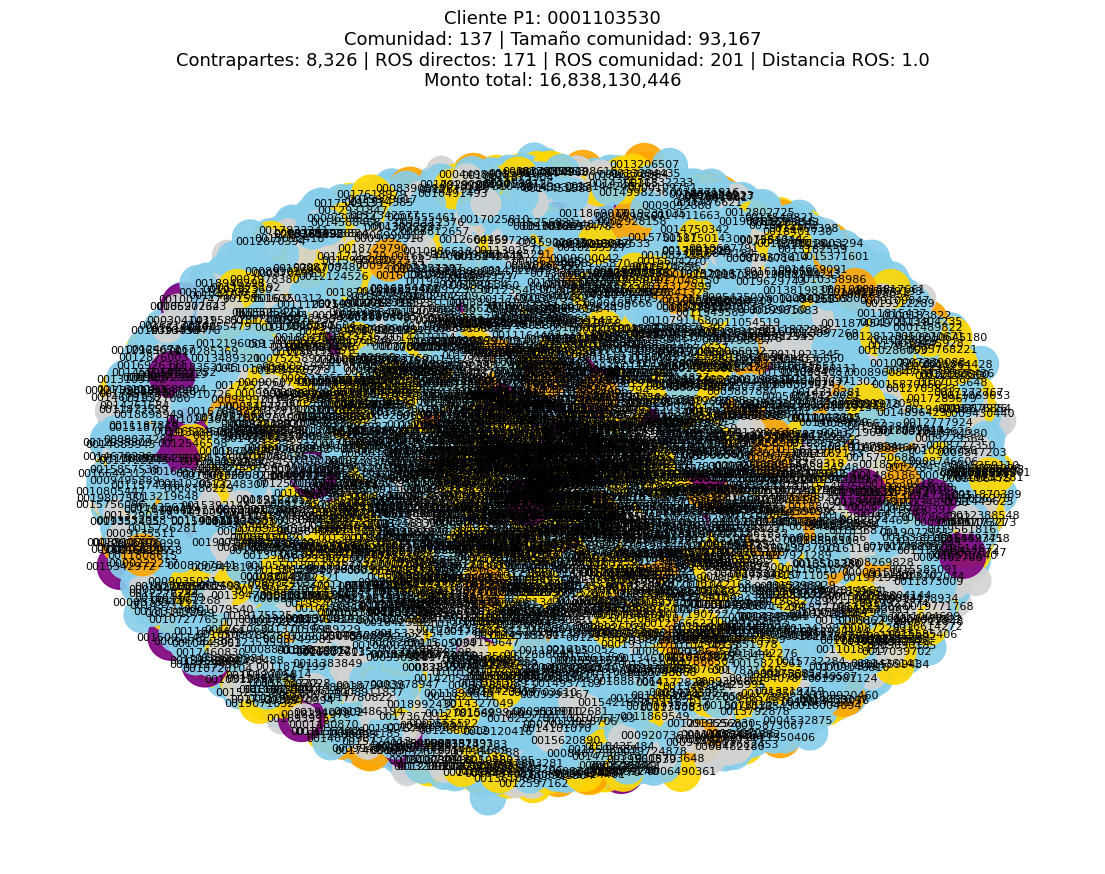

In [141]:
graficar_investigacion(
    G,
    cliente_a,
    features_p1,
    radio=1
)

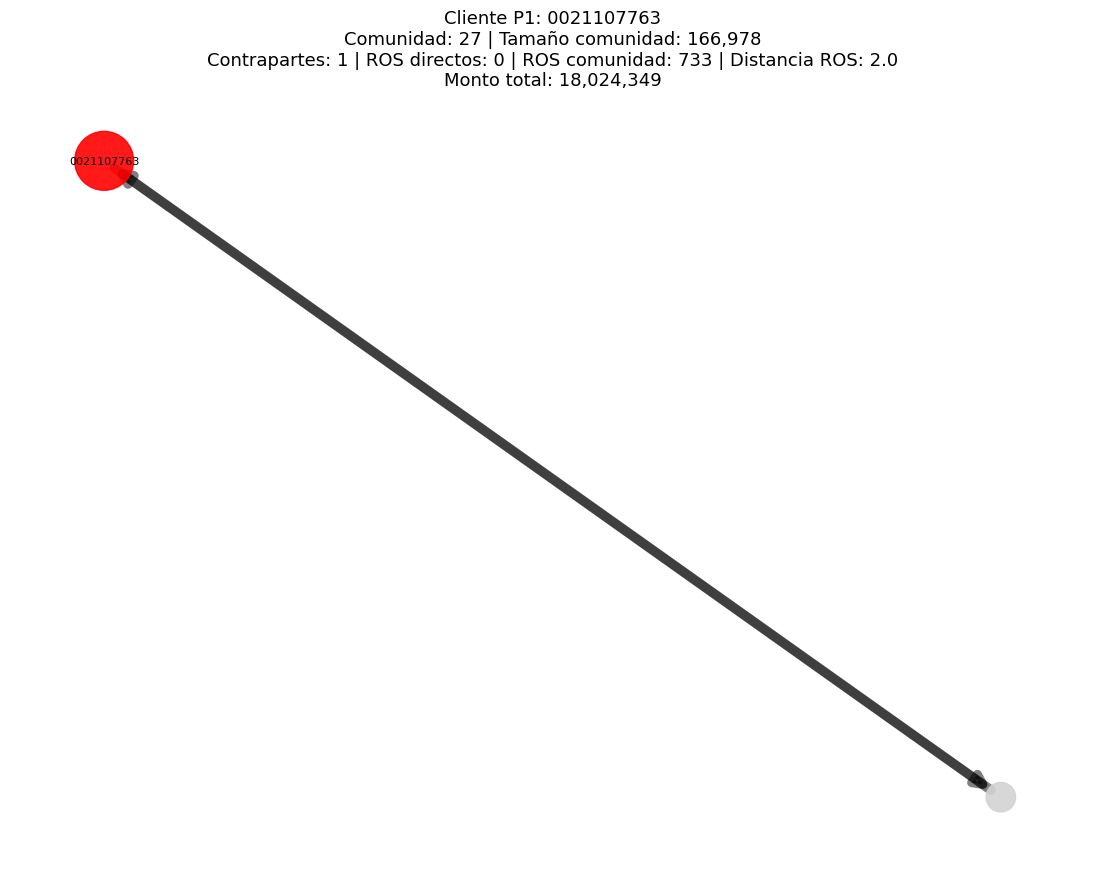

In [142]:
graficar_investigacion(
    G,
    cliente_b,
    features_p1,
    radio=1
)

In [143]:
casos_3 = features_p1[
    features_p1["degree_total"] == 3
].copy()

print("Cantidad de P1 con 3 contrapartes:", len(casos_3))

casos_3[
    [
        "node_id",
        "comunidad",
        "monto_enviado",
        "monto_recibido",
        "monto_total",
        "n_vecinos_ros",
        "n_vecinos_alerta",
        "n_ros",
        "distancia_ros"
    ]
].sort_values(
    "monto_total",
    ascending=False
).head(20)

Cantidad de P1 con 3 contrapartes: 2031


,node_id,comunidad,monto_enviado,monto_recibido,monto_total,n_vecinos_ros,n_vecinos_alerta,n_ros,distancia_ros
16164,0017288827,1,11250000.00,53.10,11250053.10,0,2,206,2.00
8870,0016697325,1,0.00,9894997.26,9894997.26,0,1,206,2.00
12340,0015608422,3692,3199660.65,3222387.00,6422047.65,0,2,14,2.00
4229,0017852409,20695,100800.00,5429035.44,5529835.44,0,1,209,2.00
16205,0018623610,14563,3601881.00,1376460.00,4978341.00,0,0,0,NaN
6042,0016671386,1,3705966.81,530960.49,4236927.30,0,1,206,2.00
8788,0022223437,1,16120.80,3489850.35,3505971.15,0,1,206,2.00
3112,0014214020,1,2592438.48,842843.97,3435282.45,0,1,206,2.00
5100,0021324114,1,1207703.97,1601079.57,2808783.54,0,1,206,2.00
4520,0015351665,3,0.00,2727571.59,2727571.59,0,0,25,2.00


In [144]:
features_p1[
    features_p1["node_id"].isin(
        ["0008264985", "0016251583"]
    )
][
    [
        "node_id",
        "comunidad",
        "cantidad_nodos",
        "in_degree",
        "out_degree",
        "degree_total",
        "monto_enviado",
        "monto_recibido",
        "monto_total",
        "n_vecinos_ros",
        "pct_vecinos_ros",
        "n_vecinos_alerta",
        "pct_vecinos_alerta",
        "n_ros",
        "pct_ros",
        "distancia_ros"
    ]
]

,node_id,comunidad,cantidad_nodos,in_degree,out_degree,degree_total,monto_enviado,monto_recibido,monto_total,n_vecinos_ros,pct_vecinos_ros,n_vecinos_alerta,pct_vecinos_alerta,n_ros,pct_ros,distancia_ros
2700,0016251583,9,196353,1,1,2,36725.40,109138412.52,109175137.92,1,0.50,2,1.00,407,0.00,1.00
8972,0008264985,137,93167,1,5,6,4219823640.24,4551.75,4219828191.99,0,0.00,6,1.00,201,0.00,2.00


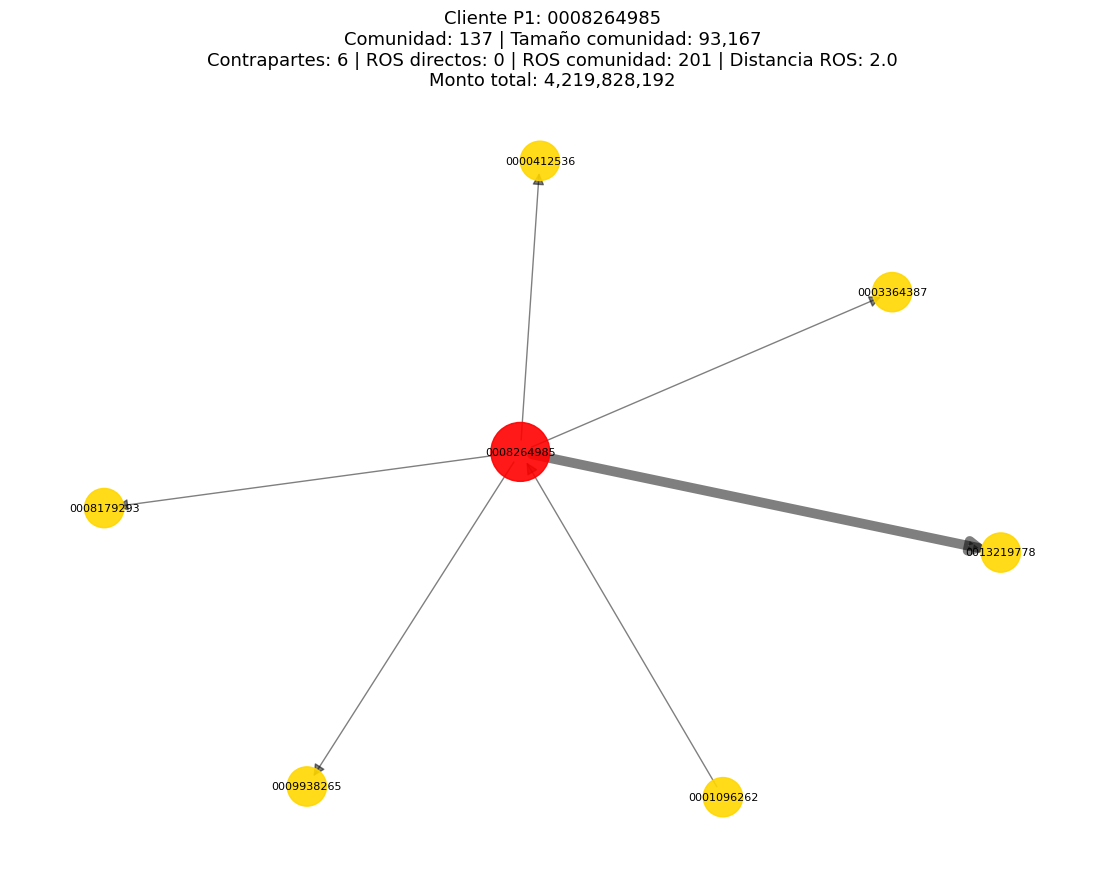

In [145]:
graficar_investigacion(
    G,
    "0008264985",
    features_p1,
    radio=1
)

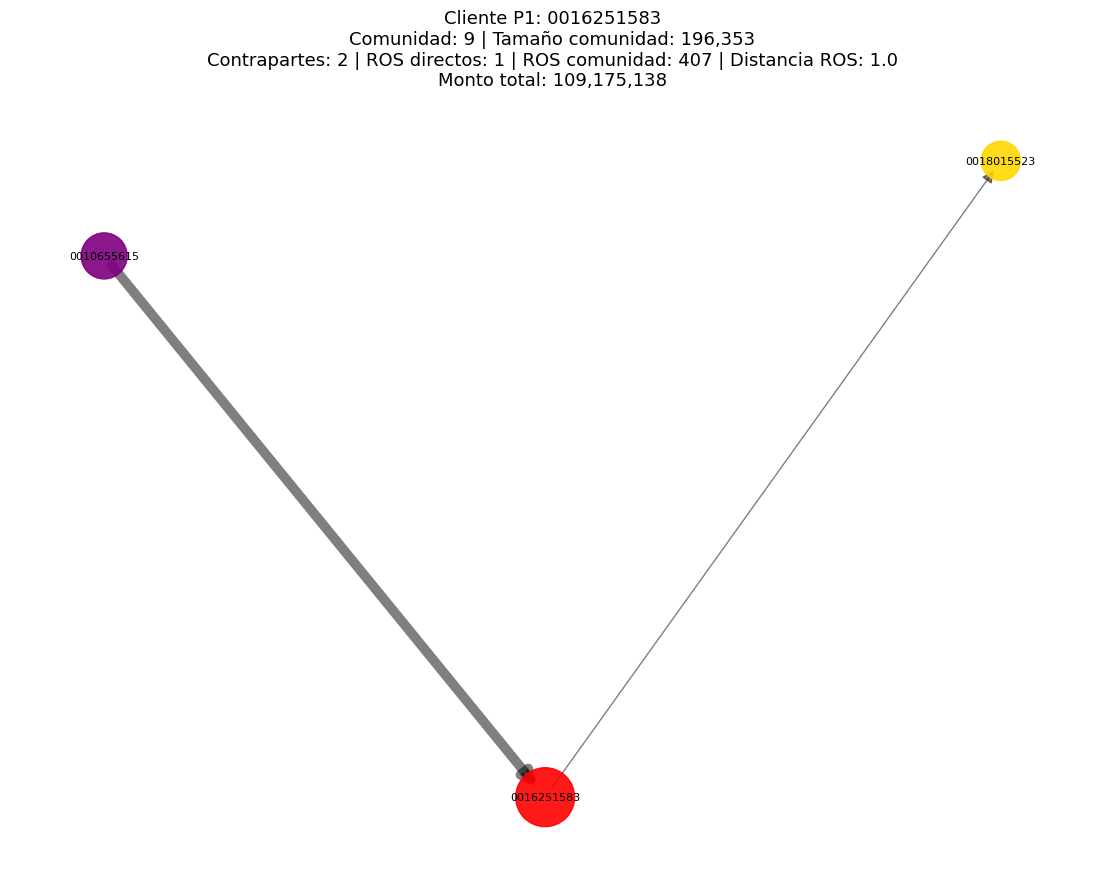

In [146]:
graficar_investigacion(
    G,
    "0016251583",
    features_p1,
    radio=1
)

In [147]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np


def graficar_investigacion(
    G,
    cliente,
    features_p1,
    radio=1,
    mostrar=True
):

    if cliente not in G:
        print(f"Cliente {cliente} no está en el grafo")
        return None

    fila = features_p1.loc[
        features_p1["node_id"] == cliente
    ]

    if fila.empty:
        print(f"Cliente {cliente} sin información en features_p1")
        return None

    fila = fila.iloc[0]

    # ==============================
    # EGO NETWORK
    # ==============================

    G_local = G.to_undirected()

    nodos_ego = list(
        nx.single_source_shortest_path_length(
            G_local,
            cliente,
            cutoff=radio
        ).keys()
    )

    ego = G.subgraph(nodos_ego).copy()

    # ==============================
    # POSICIONES
    # ==============================

    pos = nx.spring_layout(
        ego,
        seed=42,
        k=1.8
    )

    # ==============================
    # NODOS
    # ==============================

    colores = []
    tamanios = []

    for nodo in ego.nodes:

        attrs = G.nodes[nodo]

        if nodo == cliente:
            colores.append("red")
            tamanios.append(1800)

        elif attrs.get("flag_ros", 0) == 1:
            colores.append("purple")
            tamanios.append(1100)

        elif attrs.get("flag_pep", 0) == 1:
            colores.append("orange")
            tamanios.append(900)

        elif attrs.get("flag_alerta", 0) == 1:
            colores.append("gold")
            tamanios.append(800)

        elif attrs.get("flag_noticia", 0) == 1:
            colores.append("skyblue")
            tamanios.append(650)

        else:
            colores.append("lightgray")
            tamanios.append(450)

    # ==============================
    # GROSOR DE ARISTAS
    # ==============================

    montos = [
        data.get("monto_total", 0)
        for _, _, data in ego.edges(data=True)
    ]

    if len(montos) > 0:

        max_monto = max(montos)

        widths = [
            1 + 6 * (m / max_monto)
            if max_monto > 0
            else 1
            for m in montos
        ]

    else:
        widths = 1

    # ==============================
    # FIGURA
    # ==============================

    fig, ax = plt.subplots(
        figsize=(14, 9)
    )

    nx.draw_networkx_nodes(
        ego,
        pos,
        node_color=colores,
        node_size=tamanios,
        alpha=0.9,
        ax=ax
    )

    nx.draw_networkx_edges(
        ego,
        pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=18,
        width=widths,
        alpha=0.5,
        ax=ax
    )

    # ==============================
    # LABELS
    # ==============================

    labels = {}

    for nodo in ego.nodes:

        attrs = G.nodes[nodo]

        if (
            nodo == cliente
            or attrs.get("flag_ros", 0) == 1
            or attrs.get("flag_pep", 0) == 1
            or attrs.get("flag_alerta", 0) == 1
        ):
            labels[nodo] = nodo

    nx.draw_networkx_labels(
        ego,
        pos,
        labels=labels,
        font_size=8,
        ax=ax
    )

    # ==============================
    # MONTOS EN LAS ARISTAS
    # ==============================

    edge_labels = {}

    for origen, destino, attrs in ego.edges(data=True):

        monto = attrs.get("monto_total", 0)

        if monto >= 1_000_000:
            texto = f"{monto/1_000_000:.1f}M"

        elif monto >= 1_000:
            texto = f"{monto/1_000:.1f}K"

        else:
            texto = f"{monto:,.0f}"

        edge_labels[(origen, destino)] = texto

    nx.draw_networkx_edge_labels(
        ego,
        pos,
        edge_labels=edge_labels,
        font_size=8,
        ax=ax
    )

    # ==============================
    # TITULO
    # ==============================

    distancia_ros = fila.get(
        "distancia_ros",
        np.nan
    )

    titulo = (
        f"Cliente P1: {cliente}\n"
        f"Comunidad: {fila.get('comunidad')} | "
        f"Tamaño comunidad: {fila.get('cantidad_nodos'):,.0f}\n"
        f"Contrapartes: {fila.get('degree_total'):,.0f} | "
        f"ROS directos: {fila.get('n_vecinos_ros'):,.0f} | "
        f"ROS comunidad: {fila.get('n_ros'):,.0f} | "
        f"Distancia ROS: {distancia_ros}\n"
        f"Monto total: {fila.get('monto_total'):,.0f}"
    )

    ax.set_title(
        titulo,
        fontsize=13
    )

    ax.axis("off")

    plt.tight_layout()

    if mostrar:
        plt.show()

    return fig

In [148]:
descripcion_variables = {
    
    "node_id": (
        "Identificador único del cliente investigado."
    ),

    "grupo_score": (
        "Grupo de priorización asignado por el modelo. "
        "En este análisis se trabaja sobre clientes P1."
    ),

    "score": (
        "Score generado por el modelo de priorización PLAFT."
    ),

    "comunidad": (
        "Identificador de la comunidad detectada mediante Louvain. "
        "Clientes dentro de una misma comunidad presentan una "
        "mayor densidad de relaciones transaccionales entre sí."
    ),

    "cantidad_nodos": (
        "Cantidad total de clientes que forman parte de la comunidad."
    ),

    "in_degree": (
        "Cantidad de contrapartes distintas desde las cuales "
        "el cliente recibió transacciones."
    ),

    "out_degree": (
        "Cantidad de contrapartes distintas hacia las cuales "
        "el cliente envió transacciones."
    ),

    "degree_total": (
        "Cantidad de contrapartes únicas con las cuales "
        "el cliente mantiene relaciones transaccionales."
    ),

    "monto_enviado": (
        "Monto total enviado por el cliente hacia sus contrapartes."
    ),

    "monto_recibido": (
        "Monto total recibido por el cliente desde sus contrapartes."
    ),

    "monto_total": (
        "Suma del monto enviado y recibido."
    ),

    "n_vecinos_ros": (
        "Cantidad de contrapartes directas del cliente que poseen ROS."
    ),

    "pct_vecinos_ros": (
        "Porcentaje de las contrapartes directas que poseen ROS."
    ),

    "distancia_ros": (
        "Cantidad mínima de saltos en la red hasta encontrar un nodo "
        "con ROS. 0 = el propio cliente tiene ROS, "
        "1 = contraparte directa, 2 = un intermediario, etc."
    ),

    "n_ros": (
        "Cantidad total de clientes con ROS dentro de la comunidad."
    ),

    "pct_ros": (
        "Proporción de clientes con ROS dentro de la comunidad."
    ),

    "n_vecinos_alerta": (
        "Cantidad de contrapartes directas que poseen flag de alerta."
    ),

    "pct_vecinos_alerta": (
        "Porcentaje de contrapartes directas con flag de alerta."
    ),

    "n_alertas": (
        "Cantidad total de clientes con alerta dentro de la comunidad."
    ),

    "pct_alertas": (
        "Proporción de clientes con alerta dentro de la comunidad."
    ),

    "n_pep": (
        "Cantidad de clientes PEP presentes dentro de la comunidad."
    ),

    "pct_pep": (
        "Proporción de clientes PEP dentro de la comunidad."
    ),

    "n_noticias": (
        "Cantidad de clientes con noticias dentro de la comunidad."
    ),

    "pct_noticias": (
        "Proporción de clientes con noticias dentro de la comunidad."
    )
}

In [149]:
import io
import base64


def figura_a_base64(fig):

    buffer = io.BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=130,
        bbox_inches="tight"
    )

    buffer.seek(0)

    imagen_base64 = base64.b64encode(
        buffer.read()
    ).decode("utf-8")

    buffer.close()

    plt.close(fig)

    return imagen_base64

In [174]:
columnas_ejemplo = [
    "node_id",
    "grupo_score",
    "score",
    "comunidad",
    "cantidad_nodos",

    "degree_total",

    "monto_enviado",
    "monto_recibido",
    "monto_total",

    "n_vecinos_ros",
    "distancia_ros",

    "n_ros",
    "pct_ros",

    "n_vecinos_alerta",
    "pct_vecinos_alerta",

    "n_alertas",
    "pct_alertas",

    "n_pep",
    "pct_pep",

    "n_noticias",
    "pct_noticias"
]

In [177]:
tabla_ejemplo = (
    features_p1[columnas_ejemplo]
    .head(10)
    .copy()
)

In [178]:
for col in [
    "monto_enviado",
    "monto_recibido",
    "monto_total"
]:
    tabla_ejemplo[col] = tabla_ejemplo[col].map(
        lambda x: f"{x:,.2f}"
        if pd.notna(x)
        else ""
    )

In [179]:
variables_df = pd.DataFrame(
    [
        {
            "Variable": variable,
            "Funcionalidad / interpretación": descripcion
        }
        for variable, descripcion
        in descripcion_variables.items()
    ]
)

variables_html = variables_df.to_html(
    index=False,
    classes="tabla-variables",
    border=0
)

In [180]:
cliente_1 = "0008264985"
cliente_2 = "0016251583"

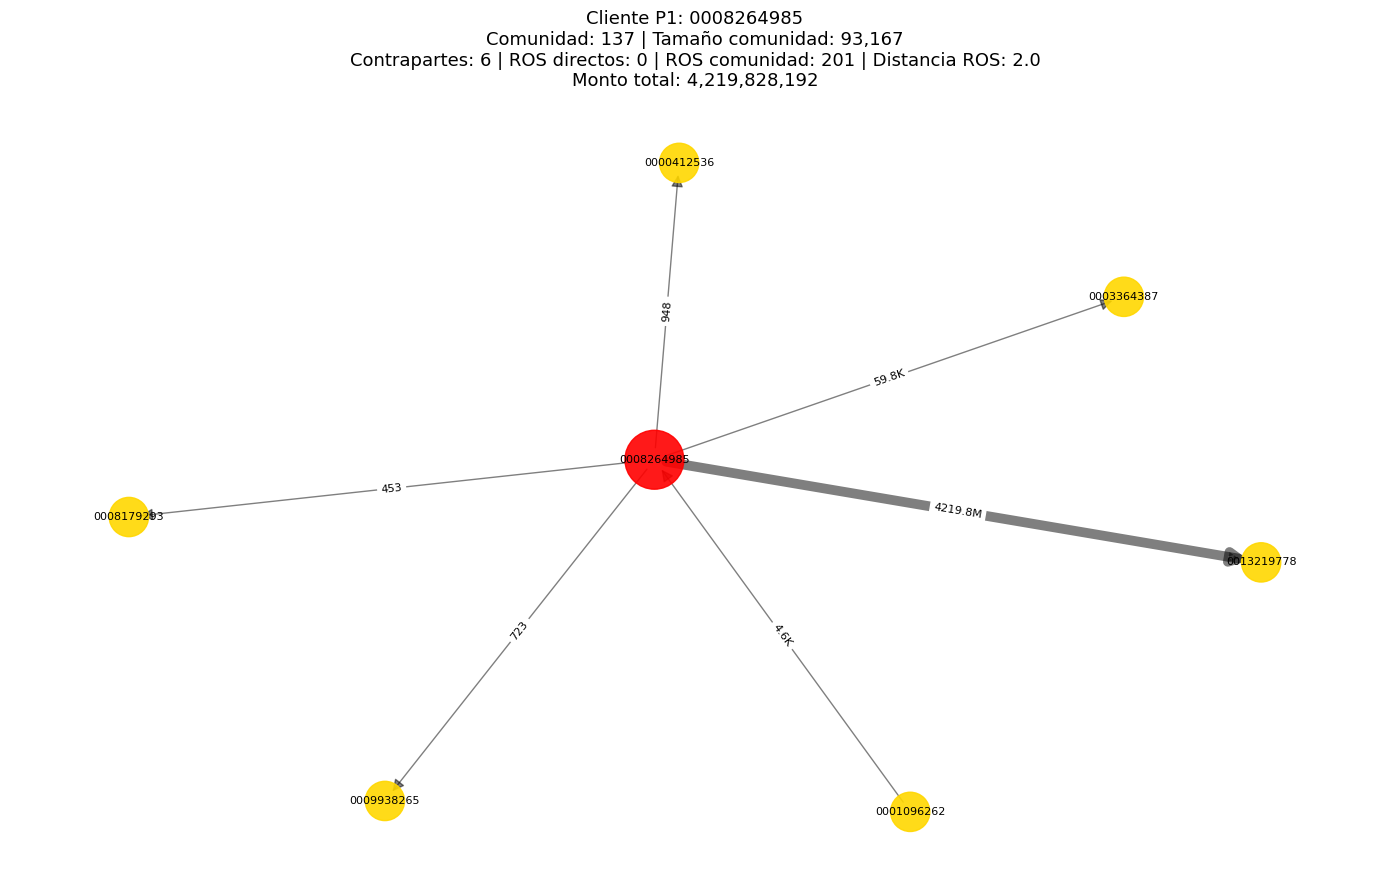

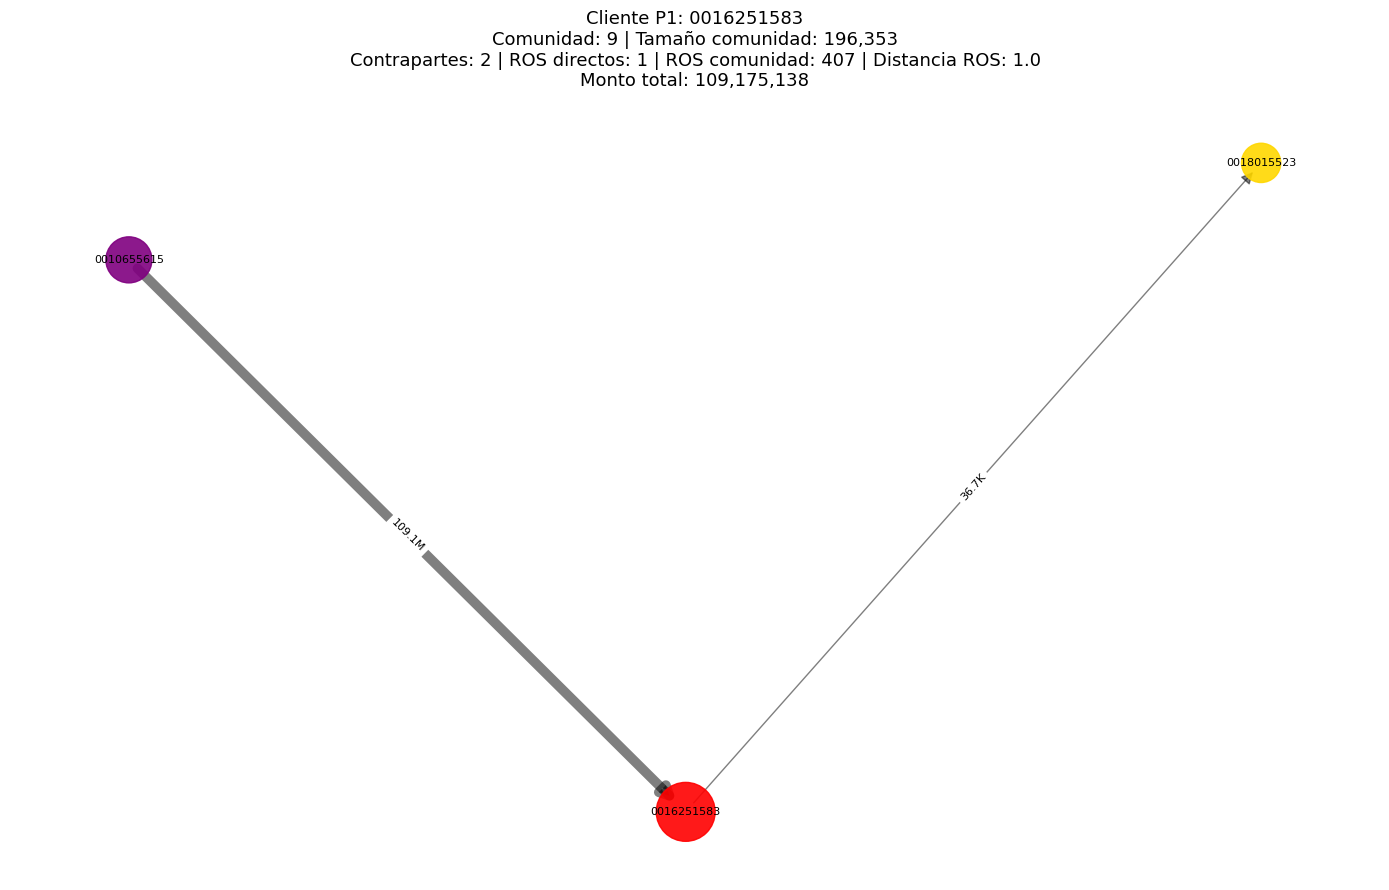

In [155]:
fig_1 = graficar_investigacion(
    G,
    cliente_1,
    features_p1,
    radio=1,
    mostrar=False
)

fig_2 = graficar_investigacion(
    G,
    cliente_2,
    features_p1,
    radio=1,
    mostrar=False
)

In [156]:
img_1 = figura_a_base64(fig_1)
img_2 = figura_a_base64(fig_2)

In [181]:
def obtener_ficha(features_p1, cliente):

    fila = (
        features_p1[
            features_p1["node_id"] == cliente
        ]
        .iloc[0]
    )

    return {
        "Cliente": cliente,
        "Comunidad": fila.get("comunidad"),
        "Tamaño comunidad": fila.get("cantidad_nodos"),
        "Contrapartes": fila.get("degree_total"),
        "Monto enviado": fila.get("monto_enviado"),
        "Monto recibido": fila.get("monto_recibido"),
        "Monto total": fila.get("monto_total"),
        "ROS directos": fila.get("n_vecinos_ros"),
        "Distancia ROS": fila.get("distancia_ros"),
        "ROS comunidad": fila.get("n_ros"),
        "Alertas directas": fila.get("n_vecinos_alerta"),
        "Porcentaje alertas": fila.get("pct_alertas"),
        "Número PEP": fila.get("n_pep"),
        "Porcentaje PEP": fila.get("pct_pep"),
        "Número noticias": fila.get("n_noticias"),
        "Porcentaje noticias": fila.get("pct_noticias")



    }

In [182]:
ficha_1 = obtener_ficha(
    features_p1,
    cliente_1
)

ficha_2 = obtener_ficha(
    features_p1,
    cliente_2
)

In [183]:
def ficha_a_html(ficha):

    filas = ""

    for clave, valor in ficha.items():

        if isinstance(valor, (float, np.floating)):

            if "Monto" in clave:
                valor = f"{valor:,.2f}"

            elif not pd.isna(valor):
                valor = f"{valor:,.2f}"

        filas += f"""
        <tr>
            <td>{clave}</td>
            <td>{valor}</td>
        </tr>
        """

    return f"""
    <table class="ficha">
        {filas}
    </table>
    """

In [184]:
ficha_1_html = ficha_a_html(ficha_1)
ficha_2_html = ficha_a_html(ficha_2)

In [185]:
html = f"""
<!DOCTYPE html>

<html lang="es">

<head>

<meta charset="UTF-8">

<title>Grafo Transaccional PLAFT</title>

<style>

body {{
    font-family: Arial, Helvetica, sans-serif;
    background: #f4f6f8;
    color: #1f2937;
    margin: 0;
}}

.container {{
    width: 94%;
    max-width: 1500px;
    margin: auto;
}}

.header {{
    background: linear-gradient(
        135deg,
        #0b4f6c,
        #0f766e
    );

    color: white;
    padding: 45px;
    margin-bottom: 30px;
}}

.header h1 {{
    margin: 0;
    font-size: 36px;
}}

.header p {{
    font-size: 17px;
    opacity: 0.9;
}}

.section {{
    background: white;
    padding: 30px;
    margin-bottom: 25px;
    border-radius: 12px;

    box-shadow:
        0 3px 10px
        rgba(0,0,0,0.06);
}}

h2 {{
    color: #0b4f6c;
    border-bottom: 2px solid #0f766e;
    padding-bottom: 8px;
}}

h3 {{
    color: #0f766e;
}}

.intro {{
    font-size: 16px;
    line-height: 1.6;
}}

.destacado {{
    background: #e8f3f1;
    border-left: 5px solid #0f766e;
    padding: 15px;
    margin: 20px 0;
}}

.tabla-datos,
.tabla-variables,
.ficha {{
    border-collapse: collapse;
    width: 100%;
    font-size: 13px;
}}

.tabla-datos th,
.tabla-variables th,
.ficha th {{
    background: #0b4f6c;
    color: white;
    padding: 9px;
}}

.tabla-datos td,
.tabla-variables td,
.ficha td {{
    border-bottom: 1px solid #ddd;
    padding: 8px;
}}

.tabla-datos tr:nth-child(even),
.tabla-variables tr:nth-child(even) {{
    background: #f8fafc;
}}

.caso {{
    display: grid;
    grid-template-columns: 32% 68%;
    gap: 20px;
    align-items: start;
}}

.ficha {{
    background: #fafafa;
}}

.ficha td:first-child {{
    font-weight: bold;
    color: #475467;
    width: 52%;
}}

.ficha td:last-child {{
    text-align: right;
}}

.grafico img {{
    width: 100%;
    border-radius: 10px;
}}

.leyenda {{
    display: flex;
    gap: 20px;
    flex-wrap: wrap;
    margin-top: 20px;
}}

.item-leyenda {{
    font-size: 13px;
}}

.circulo {{
    width: 14px;
    height: 14px;
    display: inline-block;
    border-radius: 50%;
    margin-right: 5px;
}}

.rojo {{ background:red; }}
.violeta {{ background:purple; }}
.naranja {{ background:orange; }}
.amarillo {{ background:gold; }}
.celeste {{ background:skyblue; }}
.gris {{ background:lightgray; }}

.bloque-riesgo {{
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 15px;
    margin-top: 20px;
}}

.tarjeta {{
    background: #f8fafc;
    border: 1px solid #d9e1e7;
    border-radius: 10px;
    padding: 15px;
}}

.tarjeta h4 {{
    color: #0b4f6c;
    margin: 0 0 8px;
}}

.tarjeta p {{
    margin: 0;
    font-size: 13px;
    line-height: 1.5;
}}

@media(max-width:900px) {{

    .caso {{
        grid-template-columns: 1fr;
    }}

    .bloque-riesgo {{
        grid-template-columns: 1fr;
    }}

}}

</style>

</head>


<body>

<div class="header">

    <div class="container">

        <h1>
            Grafo Transaccional PLAFT
        </h1>

        <p>
            Análisis de clientes P1,
            exposición a riesgo y
            estructura de comunidades
        </p>

    </div>

</div>


<div class="container">


<div class="section">

<h2>1. Objetivo</h2>

<p class="intro">

El objetivo del análisis es complementar
la priorización tradicional de alertas PLAFT
con información de estructura de red.

Para cada cliente P1 se analiza:

</p>

<ul>

<li>
cantidad y dirección de relaciones transaccionales;
</li>

<li>
montos enviados y recibidos;
</li>

<li>
exposición directa a clientes con ROS,
PEP, alertas o noticias;
</li>

<li>
comunidad transaccional a la cual pertenece;
</li>

<li>
proximidad estructural a clientes con ROS;
</li>

<li>
concentración de señales de riesgo dentro
de su comunidad.
</li>

</ul>

</div>



<div class="section">

<h2>2. Ejemplo de salida analítica</h2>

<p>

Cada fila representa un cliente P1
y consolida información del modelo,
de su red directa y de la comunidad
a la que pertenece.

</p>

<div style="overflow-x:auto">

{tabla_html}

</div>

</div>



<div class="section">

<h2>3. Interpretación de las variables</h2>

<p>

Las variables están diseñadas para responder
preguntas específicas durante una investigación
PLAFT.

</p>

<div style="overflow-x:auto">

{variables_html}

</div>

</div>



<div class="section">

<h2>4. Caso de investigación: {cliente_1}</h2>

<div class="caso">

<div>

<h3>Ficha del cliente</h3>

{ficha_1_html}

</div>


<div class="grafico">

<img
src="data:image/png;base64,{img_1}"
>

</div>

</div>


<div class="destacado">

Este caso permite observar un cliente P1
con pocas contrapartes directas.

El gráfico permite analizar simultáneamente
el volumen transaccionado, la dirección de las relaciones
y la presencia de señales de riesgo en sus contrapartes.

</div>

</div>



<div class="section">

<h2>5. Caso de investigación: {cliente_2}</h2>

<div class="caso">

<div>

<h3>Ficha del cliente</h3>

{ficha_2_html}

</div>


<div class="grafico">

<img
src="data:image/png;base64,{img_2}"
>

</div>

</div>


<div class="destacado">

Este caso permite analizar no sólo el riesgo directo
del cliente, sino también el nivel de riesgo presente
dentro de la comunidad transaccional a la que pertenece.

</div>

</div>



<div class="section">

<h2>6. Cómo interpretar la ficha de investigación</h2>

<div class="bloque-riesgo">

<div class="tarjeta">

<h4>Riesgo directo</h4>

<p>

<b>ROS directos</b><br>
Cantidad de contrapartes directas con ROS.

<br><br>

<b>Alertas directas</b><br>
Cantidad de contrapartes directas con señales de alerta.

<br><br>

<b>Distancia ROS</b><br>
Cantidad mínima de saltos hasta el ROS más cercano.

</p>

</div>


<div class="tarjeta">

<h4>Riesgo de comunidad</h4>

<p>

<b>ROS comunidad</b><br>
Cantidad de clientes con ROS dentro de la comunidad.

<br><br>

<b>Porcentaje alertas</b><br>
Proporción de clientes con alertas dentro de la comunidad.

<br><br>

<b>Número y porcentaje PEP</b><br>
Presencia de PEP dentro del entorno transaccional.

</p>

</div>


<div class="tarjeta">

<h4>Noticias y contexto</h4>

<p>

<b>Número noticias</b><br>
Cantidad de clientes con noticias identificadas
dentro de la comunidad.

<br><br>

<b>Porcentaje noticias</b><br>
Proporción de clientes con noticias respecto
del total de la comunidad.

</p>

</div>

</div>

</div>



<div class="section">

<h2>7. Leyenda del grafo</h2>

<div class="leyenda">

<div class="item-leyenda">
<span class="circulo rojo"></span>
Cliente P1 investigado
</div>

<div class="item-leyenda">
<span class="circulo violeta"></span>
Cliente con ROS
</div>

<div class="item-leyenda">
<span class="circulo naranja"></span>
PEP
</div>

<div class="item-leyenda">
<span class="circulo amarillo"></span>
Cliente con alerta
</div>

<div class="item-leyenda">
<span class="circulo celeste"></span>
Cliente con noticia
</div>

<div class="item-leyenda">
<span class="circulo gris"></span>
Sin señal de riesgo identificada
</div>

</div>

</div>



<div class="section">

<h2>8. Lectura para el analista PLAFT</h2>

<div class="destacado">

<b>Riesgo directo:</b>
n_vecinos_ros,
n_vecinos_alerta,
n_vecinos_pep.

<br><br>

<b>Riesgo estructural:</b>
comunidad,
n_ros,
pct_ros,
distancia_ros.

<br><br>

<b>Riesgo de comunidad:</b>
n_alertas,
pct_alertas,
n_pep,
pct_pep,
n_noticias,
pct_noticias.

<br><br>

<b>Comportamiento transaccional:</b>
degree_total,
monto_enviado,
monto_recibido,
monto_total.

</div>

<p>

La combinación de estos niveles permite
diferenciar clientes que pueden tener
un volumen elevado por su actividad habitual
de aquellos que presentan estructuras
de relación especialmente relevantes
para una investigación PLAFT.

</p>

<p>

El análisis de comunidad permite además identificar
situaciones donde el cliente no presenta una relación
directa con un ROS o un PEP, pero sí se encuentra
insertado dentro de una red con una concentración
significativa de señales de riesgo.

</p>

</div>


</div>

</body>

</html>
"""

In [168]:
html = f"""
<!DOCTYPE html>

<html lang="es">

<head>

<meta charset="UTF-8">

<title>Grafo Transaccional PLAFT</title>

<style>

body {{
    font-family: Arial, Helvetica, sans-serif;
    background: #f4f6f8;
    color: #1f2937;
    margin: 0;
}}

.container {{
    width: 94%;
    max-width: 1500px;
    margin: auto;
}}

.header {{
    background: linear-gradient(
        135deg,
        #0b4f6c,
        #0f766e
    );

    color: white;

    padding: 45px;

    margin-bottom: 30px;
}}

.header h1 {{
    margin: 0;
    font-size: 36px;
}}

.header p {{
    font-size: 17px;
    opacity: 0.9;
}}

.section {{
    background: white;
    padding: 30px;
    margin-bottom: 25px;
    border-radius: 12px;

    box-shadow:
        0 3px 10px
        rgba(0,0,0,0.06);
}}

h2 {{
    color: #0b4f6c;
    border-bottom: 2px solid #0f766e;
    padding-bottom: 8px;
}}

h3 {{
    color: #0f766e;
}}

.intro {{
    font-size: 16px;
    line-height: 1.6;
}}

.destacado {{
    background: #e8f3f1;
    border-left: 5px solid #0f766e;
    padding: 15px;
    margin: 20px 0;
}}

.tabla-datos,
.tabla-variables,
.ficha {{

    border-collapse: collapse;
    width: 100%;
    font-size: 13px;
}}

.tabla-datos th,
.tabla-variables th,
.ficha th {{

    background: #0b4f6c;
    color: white;
    padding: 9px;
}}

.tabla-datos td,
.tabla-variables td,
.ficha td {{

    border-bottom: 1px solid #ddd;
    padding: 8px;
}}

.tabla-datos tr:nth-child(even),
.tabla-variables tr:nth-child(even) {{

    background: #f8fafc;
}}

.caso {{

    display: grid;

    grid-template-columns:
        30% 70%;

    gap: 20px;

    align-items: start;
}}

.ficha {{
    background: #fafafa;
}}

.ficha td:first-child {{
    font-weight: bold;
    color: #475467;
}}

.grafico img {{
    width: 100%;
    border-radius: 10px;
}}

.leyenda {{
    display: flex;
    gap: 20px;
    flex-wrap: wrap;
    margin-top: 20px;
}}

.item-leyenda {{
    font-size: 13px;
}}

.circulo {{
    width: 14px;
    height: 14px;
    display: inline-block;
    border-radius: 50%;
    margin-right: 5px;
}}

.rojo {{ background:red; }}
.violeta {{ background:purple; }}
.naranja {{ background:orange; }}
.amarillo {{ background:gold; }}
.celeste {{ background:skyblue; }}
.gris {{ background:lightgray; }}

@media(max-width:900px) {{

    .caso {{
        grid-template-columns: 1fr;
    }}

}}

</style>

</head>


<body>

<div class="header">

    <div class="container">

        <h1>
            Grafo Transaccional PLAFT
        </h1>

        <p>
            Análisis de clientes P1,
            exposición a riesgo y
            estructura de comunidades
        </p>

    </div>

</div>


<div class="container">


<div class="section">

<h2>1. Objetivo</h2>

<p class="intro">

El objetivo del análisis es complementar
la priorización tradicional de alertas PLAFT
con información de estructura de red.

Para cada cliente P1 se analiza:

</p>

<ul>

<li>
cantidad y dirección de relaciones
transaccionales;
</li>

<li>
montos enviados y recibidos;
</li>

<li>
exposición directa a clientes con ROS,
PEP, alertas o noticias;
</li>

<li>
comunidad transaccional a la cual
pertenece;
</li>

<li>
proximidad estructural a clientes
con ROS.

</li>

</ul>

</div>



<div class="section">

<h2>2. Ejemplo de salida analítica</h2>

<p>

Cada fila representa un cliente P1
y consolida información del modelo,
de su red directa y de la comunidad
a la que pertenece.

</p>

<div style="overflow-x:auto">

{tabla_html}

</div>

</div>



<div class="section">

<h2>3. Interpretación de las variables</h2>

<p>

Las variables están diseñadas para responder
preguntas específicas durante una investigación
PLAFT.

</p>

<div style="overflow-x:auto">

{variables_html}

</div>

</div>



<div class="section">

<h2>4. Caso de investigación: {cliente_1}</h2>

<div class="caso">

<div>

<h3>Ficha del cliente</h3>

{ficha_1_html}

</div>

<div class="grafico">

<img
src="data:image/png;base64,{img_1}"
>

</div>

</div>

<div class="destacado">

Este caso permite observar un cliente P1
con pocas contrapartes directas.
El grosor de las relaciones representa
la magnitud relativa del monto transaccionado.

</div>

</div>



<div class="section">

<h2>5. Caso de investigación: {cliente_2}</h2>

<div class="caso">

<div>

<h3>Ficha del cliente</h3>

{ficha_2_html}

</div>

<div class="grafico">

<img
src="data:image/png;base64,{img_2}"
>

</div>

</div>

<div class="destacado">

Este caso permite analizar simultáneamente
la relación directa del cliente y
la existencia de señales de riesgo
en sus contrapartes.

</div>

</div>



<div class="section">

<h2>6. Leyenda del grafo</h2>

<div class="leyenda">

<div class="item-leyenda">
<span class="circulo rojo"></span>
Cliente P1 investigado
</div>

<div class="item-leyenda">
<span class="circulo violeta"></span>
Cliente con ROS
</div>

<div class="item-leyenda">
<span class="circulo naranja"></span>
PEP
</div>

<div class="item-leyenda">
<span class="circulo amarillo"></span>
Cliente con alerta
</div>

<div class="item-leyenda">
<span class="circulo celeste"></span>
Cliente con noticia
</div>

<div class="item-leyenda">
<span class="circulo gris"></span>
Sin señal de riesgo identificada
</div>

</div>

</div>



<div class="section">

<h2>7. Lectura para el analista PLAFT</h2>

<div class="destacado">

<b>Riesgo directo:</b>
n_vecinos_ros,
n_vecinos_alerta,
n_vecinos_pep.

<br><br>

<b>Riesgo estructural:</b>
comunidad,
n_ros,
pct_ros,
distancia_ros.

<br><br>

<b>Comportamiento transaccional:</b>
degree_total,
monto_enviado,
monto_recibido,
monto_total.

</div>

<p>

La combinación de estos tres niveles permite
diferenciar clientes que pueden tener
un volumen elevado por su actividad normal
de aquellos que presentan estructuras
de relación especialmente relevantes
para una investigación PLAFT.

</p>

</div>


</div>

</body>

</html>
"""

In [186]:
archivo_salida = "reporte_grafos_plaft.html"

with open(
    archivo_salida,
    "w",
    encoding="utf-8"
) as f:

    f.write(html)


print(
    f"HTML generado correctamente: "
    f"{archivo_salida}"
)

HTML generado correctamente: reporte_grafos_plaft.html


In [187]:
import webbrowser
import os

webbrowser.open(
    "file://" +
    os.path.abspath(
        archivo_salida
    )
)

True